In [2]:
# Enhanced setup with all necessary imports AND data loading
import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Enhanced configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced for better training stability
AUTOTUNE = tf.data.AUTOTUNE

# ==================== DATA LOADING (FROM YOUR ORIGINAL CODE) ====================

# 1. Define the root directory of your dataset
DATA_ROOT = Path('/content/drive/MyDrive/fatigue_dataset/Data')

# 2. Verify data directory exists
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Dataset root directory not found: {DATA_ROOT}")

# 3. Find all class directories
class_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir()]
if not class_dirs:
    raise FileNotFoundError(f"No class subdirectories found in {DATA_ROOT}")

# 4. Create label mapping (ensure Fatigue=1, NonFatigue=0)
desired_order = ['NonFatigue', 'Fatigue']  # This ensures Fatigue gets label 1
class_names = sorted([d.name for d in class_dirs])

# Reorder to ensure correct mapping
if set(class_names) == set(desired_order):
    class_names = desired_order

label_map = {name: idx for idx, name in enumerate(class_names)}

print("Class to label mapping:")
for name, idx in label_map.items():
    print(f"  {name} -> {idx}")

# 5. Collect all image files and create records
supported_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
records = []

print(f"\n🔍 Searching for images in {DATA_ROOT}...")

for class_name in class_names:
    class_dir = DATA_ROOT / class_name
    count = 0
    for f in class_dir.rglob('*'):
        if f.is_file() and f.suffix.lower() in supported_exts:
            # Check if file is not empty
            if os.path.getsize(f) > 0:
                records.append({
                    'path': str(f.resolve()),
                    'label_name': class_name,
                    'label': label_map[class_name]
                })
                count += 1
    print(f"  Found {count} images in {class_name}")

if not records:
    raise RuntimeError(f"No image files found under {DATA_ROOT}")

# 6. Create DataFrame
df = pd.DataFrame.from_records(records)

# 7. Shuffle for randomness
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# 8. Display dataset summary
print(f"\n✅ Dataset processed successfully!")
print("="*50)
print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Total images: {len(df)}")

print("\nClass distribution:")
class_counts = df['label_name'].value_counts()
for class_name in class_names:
    count = class_counts[class_name]
    percentage = (count / len(df)) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print("\nLabel verification:")
print(df.groupby(['label_name', 'label']).size())

print("\nFirst 5 rows:")
print(df[['path', 'label_name', 'label']].head())

# 9. Check for any remaining empty files
print(f"\n🔍 Checking for empty files...")
empty_files = []
for idx, row in df.iterrows():
    if os.path.getsize(row['path']) == 0:
        empty_files.append(row['path'])

if empty_files:
    print(f"Found {len(empty_files)} empty files. Removing them...")
    # Remove empty files from dataframe
    df = df[df['path'].apply(lambda x: os.path.getsize(x) > 0)].reset_index(drop=True)
    print(f"Dataset size after removing empty files: {len(df)}")
else:
    print("✅ No empty files found")

print("="*50)
print("✅ Data loading complete! DataFrame 'df' is ready for use.")
print(f"Final dataset shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class to label mapping:
  NonFatigue -> 0
  Fatigue -> 1

🔍 Searching for images in /content/drive/MyDrive/fatigue_dataset/Data...
  Found 1100 images in NonFatigue
  Found 1100 images in Fatigue

✅ Dataset processed successfully!
Dataset root: /content/drive/MyDrive/fatigue_dataset/Data
Total images: 2200

Class distribution:
  NonFatigue: 1100 images (50.0%)
  Fatigue: 1100 images (50.0%)

Label verification:
label_name  label
Fatigue     1        1100
NonFatigue  0        1100
dtype: int64

First 5 rows:
                                                path label_name  label
0  /content/drive/MyDrive/fatigue_dataset/Data/Fa...    Fatigue      1
1  /content/drive/MyDrive/fatigue_dataset/Data/Fa...    Fatigue      1
2  /content/drive/MyDrive/fatigue_dataset/Data/Fa...    Fatigue      1
3  /content/drive/MyDrive/fatigue_dataset/Data/Fa...    Fatigue      1
4  

In [3]:
# Verification check
print(f"\n🔍 DataFrame verification:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Labels: {df['label'].unique()}")
print(f"Label names: {df['label_name'].unique()}")

# Quick sample check
sample_path = df.iloc[0]['path']
print(f"\nSample image path: {sample_path}")
print(f"File exists: {os.path.exists(sample_path)}")
print(f"File size: {os.path.getsize(sample_path)} bytes")


🔍 DataFrame verification:
Shape: (2200, 3)
Columns: ['path', 'label_name', 'label']
Labels: [1 0]
Label names: ['Fatigue' 'NonFatigue']

Sample image path: /content/drive/MyDrive/fatigue_dataset/Data/Fatigue/0425.jpg
File exists: True
File size: 17891 bytes


In [4]:
# Step 2: Create Enhanced Data Augmentation (FIXED VERSION)

# Create augmentation layer OUTSIDE of any tf.function
AUGMENTATION_LAYER = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Simplified preprocessing function without tf.function decorator for now
def load_and_preprocess_enhanced(path, label, is_training=True):
    """Enhanced preprocessing with conditional augmentation"""
    # Read and decode image
    img_data = tf.io.read_file(path)
    img = tf.image.decode_image(img_data, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)

    # Apply augmentation only during training
    if is_training:
        img = AUGMENTATION_LAYER(img, training=True)

    # Normalize to [0,1] then apply VGG preprocessing
    img = img / 255.0
    img = tf.keras.applications.vgg16.preprocess_input(img * 255.0)

    return img, tf.cast(label, tf.float32)

print("✅ Enhanced data augmentation ready (fixed version)!")

✅ Enhanced data augmentation ready (fixed version)!


In [5]:
# Step 3: Create Multi-Feature Model Architecture
def create_multi_feature_model(input_shape=(224, 224, 3)):
    """Create enhanced model with multiple feature extraction paths"""

    inputs = layers.Input(shape=input_shape, name='input_image')

    # Path 1: EfficientNet features (modern, efficient)
    efficientnet_base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    efficientnet_base.trainable = False  # Start frozen

    efficientnet_features = efficientnet_base(inputs, training=False)
    efficientnet_features = layers.GlobalAveragePooling2D(name='efficientnet_gap')(efficientnet_features)

    # Path 2: VGG16 features (good for texture patterns)
    vgg16_base = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    vgg16_base.trainable = False  # Start frozen

    vgg16_features = vgg16_base(inputs, training=False)
    vgg16_features = layers.GlobalAveragePooling2D(name='vgg16_gap')(vgg16_features)

    # Path 3: Custom lightweight CNN for domain-specific features
    x = layers.Conv2D(32, (7, 7), activation='relu', padding='same', name='custom_conv1')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same', name='custom_conv2')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='custom_conv3')(x)
    x = layers.GlobalAveragePooling2D(name='custom_gap')(x)

    custom_features = x

    # Combine all features
    combined_features = layers.Concatenate(name='feature_fusion')([
        efficientnet_features,
        vgg16_features,
        custom_features
    ])

    # Enhanced classification head with better regularization
    x = layers.Dense(512, activation='relu', name='fc1')(combined_features)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation='relu', name='fc3')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='classification')(x)

    model = models.Model(inputs, outputs, name='enhanced_fatigue_detector')
    return model

# Create the model
enhanced_model = create_multi_feature_model()
enhanced_model.summary()

print("✅ Multi-feature model created!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "enhanced_fatigue_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_conv1        │ (None, 224, 224,  │      4,736 │ input_image[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ custom_conv1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_conv2        │ (None, 112, 112,  │     51,264 │ batch_normalizat… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ custom_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ input_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_conv3        │ (None, 56, 56,    │     73,856 │ batch_normalizat… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_gap    │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_gap          │ (None, 128)       │          0 │ custom_conv3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 1920)      │          0 │ efficientnet_gap… │
│ (Concatenate)       │                   │            │ vgg16_gap[0][0],  │
│                     │                   │            │ custom_gap[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 512)       │    983,552 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 20,045,476 (76.47 MB)

 Trainable params: 1,279,489 (4.88 MB)

 Non-trainable params: 18,765,987 (71.59 MB)

✅ Multi-feature model created!


In [6]:
# Step 4: Define Advanced Loss Functions and Metrics
import tensorflow.keras.backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss for handling class imbalance"""
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        # Calculate p_t
        p_t = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)

        # Calculate alpha_t
        alpha_t = tf.where(K.equal(y_true, 1), alpha, 1 - alpha)

        # Calculate cross entropy
        cross_entropy = -K.log(p_t)

        # Calculate focal weight
        weight = alpha_t * K.pow((1 - p_t), gamma)

        # Calculate focal loss
        loss = weight * cross_entropy
        return K.mean(loss)

    return focal_loss_fixed

def f1_score(y_true, y_pred):
    """F1 score metric"""
    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

    precision_val = precision(y_true, y_pred)
    recall_val = recall(y_true, y_pred)
    return 2*((precision_val*recall_val)/(precision_val+recall_val+K.epsilon()))

print("✅ Custom loss functions ready!")

✅ Custom loss functions ready!


In [7]:
# Step 5: Prepare your data using existing dataframe (df) - FIXED VERSION

# Display current data distribution
print("Current data distribution:")
print(df['label_name'].value_counts())

# Create train/validation/test splits (same as your original approach)
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f"Split sizes -> Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# FIXED: Enhanced dataset creation function
def create_enhanced_dataset(dataframe, is_training=False, shuffle=False):
    """Create enhanced tf.data dataset - FIXED VERSION"""
    paths = dataframe['path'].values
    labels = dataframe['label'].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)

    # Create separate map functions for training and non-training
    if is_training:
        def map_func_train(path, label):
            return load_and_preprocess_enhanced(path, label, is_training=True)
        dataset = dataset.map(map_func_train, num_parallel_calls=AUTOTUNE)
    else:
        def map_func_val(path, label):
            return load_and_preprocess_enhanced(path, label, is_training=False)
        dataset = dataset.map(map_func_val, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

# Create enhanced datasets
print("Creating enhanced datasets...")
train_ds_enhanced = create_enhanced_dataset(train_df, is_training=True, shuffle=True)
val_ds_enhanced = create_enhanced_dataset(val_df, is_training=False, shuffle=False)
test_ds_enhanced = create_enhanced_dataset(test_df, is_training=False, shuffle=False)

# Verify dataset shapes
print("Verifying dataset shapes...")
for images, labels in train_ds_enhanced.take(1):
    print(f"Enhanced batch - Images shape: {images.shape}, Labels shape: {labels.shape}")
    print(f"Image data range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")

print("✅ Enhanced datasets created successfully!")

# Optional: Test one batch to make sure augmentation is working
print("\nTesting augmentation on training data...")
try:
    sample_batch_images, sample_batch_labels = next(iter(train_ds_enhanced))
    print(f"✅ Training batch loaded successfully: {sample_batch_images.shape}")

    sample_batch_images_val, sample_batch_labels_val = next(iter(val_ds_enhanced))
    print(f"✅ Validation batch loaded successfully: {sample_batch_images_val.shape}")

except Exception as e:
    print(f"❌ Error in dataset creation: {e}")

Current data distribution:
label_name
Fatigue       1100
NonFatigue    1100
Name: count, dtype: int64
Split sizes -> Train: 1760, Validation: 220, Test: 220
Creating enhanced datasets...
Verifying dataset shapes...
Enhanced batch - Images shape: (16, 224, 224, 3), Labels shape: (16,)
Image data range: [-123.680, 151.061]
✅ Enhanced datasets created successfully!

Testing augmentation on training data...
✅ Training batch loaded successfully: (16, 224, 224, 3)
✅ Validation batch loaded successfully: (16, 224, 224, 3)


In [9]:
# Step 6: Phase 1 Training - Frozen Base Models
print("🚀 Starting Phase 1: Training with frozen base models...")

# Compile model for phase 1
enhanced_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', 'precision', 'recall', f1_score]
)

# Define callbacks
callbacks_phase1 = [
    ModelCheckpoint(
        '/content/drive/MyDrive/my_models/enhanced_model_phase1.keras',
        save_best_only=True,
        monitor='val_f1_score',
        mode='max',
        verbose=1,
        save_weights_only=False
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

# Train Phase 1
EPOCHS_PHASE1 = 25

history_phase1 = enhanced_model.fit(
    train_ds_enhanced,
    epochs=EPOCHS_PHASE1,
    validation_data=val_ds_enhanced,
    callbacks=callbacks_phase1,
    verbose=1
)

print("✅ Phase 1 training complete!")

🚀 Starting Phase 1: Training with frozen base models...
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6106 - f1_score: 5.7081 - loss: 0.1313 - precision: 0.6725 - recall: 0.4217
Epoch 1: val_f1_score improved from -inf to 7.39349, saving model to /content/drive/MyDrive/my_models/enhanced_model_phase1.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.6107 - f1_score: 5.7089 - loss: 0.1313 - precision: 0.6726 - recall: 0.4217 - val_accuracy: 0.8136 - val_f1_score: 7.3935 - val_loss: 0.0553 - val_precision: 0.8485 - val_recall: 0.7636 - learning_rate: 0.0010
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6277 - f1_score: 5.5547 - loss: 0.0991 - precision: 0.6956 - recall: 0.4194
Epoch 2: val_f1_score did not improve from 7.39349
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 416ms/step - accuracy: 0.6277 - f1_score: 5.5551 - loss: 0.0991 - precision: 0.6959 - recall: 0.4194 - val_accuracy: 0.6682 - val_f1_score: 4.1013 - val_loss: 0.0505 - val_precisi

In [13]:
# Step 7: Phase 2 - Fine-tuning
print("🚀 Starting Phase 2: Fine-tuning...")

# Load the best model from Phase 1
enhanced_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/my_models/enhanced_model_phase1.keras',
    custom_objects={'focal_loss_fixed': focal_loss(), 'f1_score': f1_score}
)

# Unfreeze top layers for fine-tuning
def unfreeze_top_layers(model, layers_to_unfreeze=10):
    """Unfreeze top layers of the base models for fine-tuning"""
    for layer in model.layers:
        if hasattr(layer, 'layers'):  # This is a nested model
            if 'efficientnet' in layer.name.lower():
                layer.trainable = True
                # Freeze bottom layers, unfreeze top layers
                for sublayer in layer.layers[:-layers_to_unfreeze]:
                    sublayer.trainable = False
                print(f"EfficientNet: Unfroze top {layers_to_unfreeze} layers")

            elif 'vgg16' in layer.name.lower():
                layer.trainable = True
                # Freeze bottom layers, unfreeze top layers
                for sublayer in layer.layers[:-4]:
                    sublayer.trainable = False
                print(f"VGG16: Unfroze top 4 layers")

# Unfreeze layers
unfreeze_top_layers(enhanced_model)

# Recompile with lower learning rate for fine-tuning
enhanced_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Much lower learning rate
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', 'precision', 'recall', f1_score]
)

# New callbacks for Phase 2
callbacks_phase2 = [
    ModelCheckpoint(
        '/content/drive/MyDrive/my_models/enhanced_model_final.keras',
        save_best_only=True,
        monitor='val_f1_score',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

# Train Phase 2
EPOCHS_PHASE2 = EPOCHS_PHASE1 + 15

history_phase2 = enhanced_model.fit(
    train_ds_enhanced,
    epochs=EPOCHS_PHASE2,
    validation_data=val_ds_enhanced,
    callbacks=callbacks_phase2,
    initial_epoch=len(history_phase1.history['loss']),
    verbose=1
)

print("✅ Phase 2 fine-tuning complete!")

🚀 Starting Phase 2: Fine-tuning...
EfficientNet: Unfroze top 10 layers
VGG16: Unfroze top 4 layers
Epoch 26/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6483 - f1_score: 5.8150 - loss: 0.0958 - precision: 0.7495 - recall: 0.4505
Epoch 26: val_f1_score improved from -inf to 4.48165, saving model to /content/drive/MyDrive/my_models/enhanced_model_final.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 96s 561ms/step - accuracy: 0.6483 - f1_score: 5.8139 - loss: 0.0958 - precision: 0.7495 - recall: 0.4505 - val_accuracy: 0.7045 - val_f1_score: 4.4816 - val_loss: 0.0480 - val_precision: 0.9787 - val_recall: 0.4182 - learning_rate: 1.0000e-05
Epoch 27/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.6354 - f1_score: 5.5154 - loss: 0.0948 - precision: 0.7583 - recall: 0.4178
Epoch 27: val_f1_score did not improve from 4.48165
110/110 ━━━━━━━━━━━━━━━━━━━━ 48s 433ms/step - accuracy: 0.6354 - f1_score: 5.5158 - loss: 0.0948 - precision: 0.7581 - recall: 0.4179 - val_accuracy: 0.6227 

📊 Starting comprehensive evaluation...
Evaluating on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.7161 - f1_score: 6.0230 - loss: 0.0708 - precision: 0.8358 - recall: 0.5274
Test Results:
  Accuracy: 0.7545
  Precision: 0.8889
  Recall: 0.5818
  F1-Score: 6.1019
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 744ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

  NonFatigue       0.69      0.93      0.79       110
     Fatigue       0.89      0.58      0.70       110

    accuracy                           0.75       220
   macro avg       0.79      0.75      0.75       220
weighted avg       0.79      0.75      0.75       220



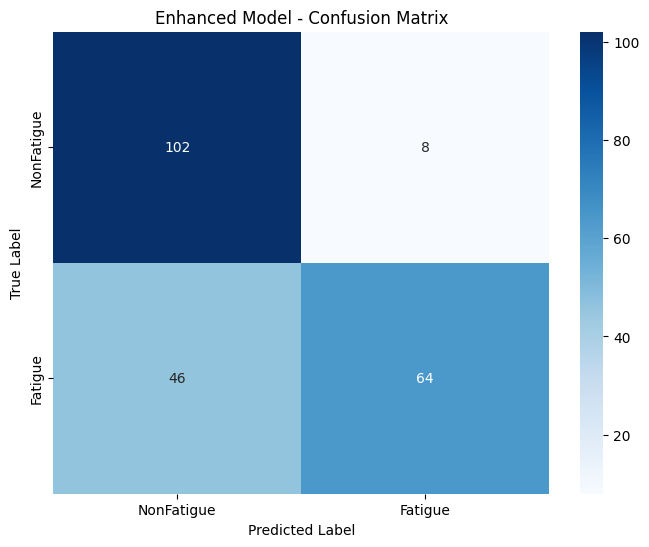


ROC AUC Score: 0.8436
✅ Evaluation complete!


In [14]:
# Step 8: Comprehensive Model Evaluation
print("📊 Starting comprehensive evaluation...")

# Load the best final model
final_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/my_models/enhanced_model_final.keras',
    custom_objects={'focal_loss_fixed': focal_loss(), 'f1_score': f1_score}
)

# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_acc, test_precision, test_recall, test_f1 = final_model.evaluate(test_ds_enhanced)

print(f"Test Results:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Get detailed predictions
y_true = np.concatenate([y for x, y in test_ds_enhanced], axis=0)
y_pred_probs = final_model.predict(test_ds_enhanced)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Classification report
print("\nDetailed Classification Report:")
target_names = ['NonFatigue', 'Fatigue']
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced Model - Confusion Matrix')
plt.show()

# ROC AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs)
print(f"\nROC AUC Score: {auc_score:.4f}")

print("✅ Evaluation complete!")

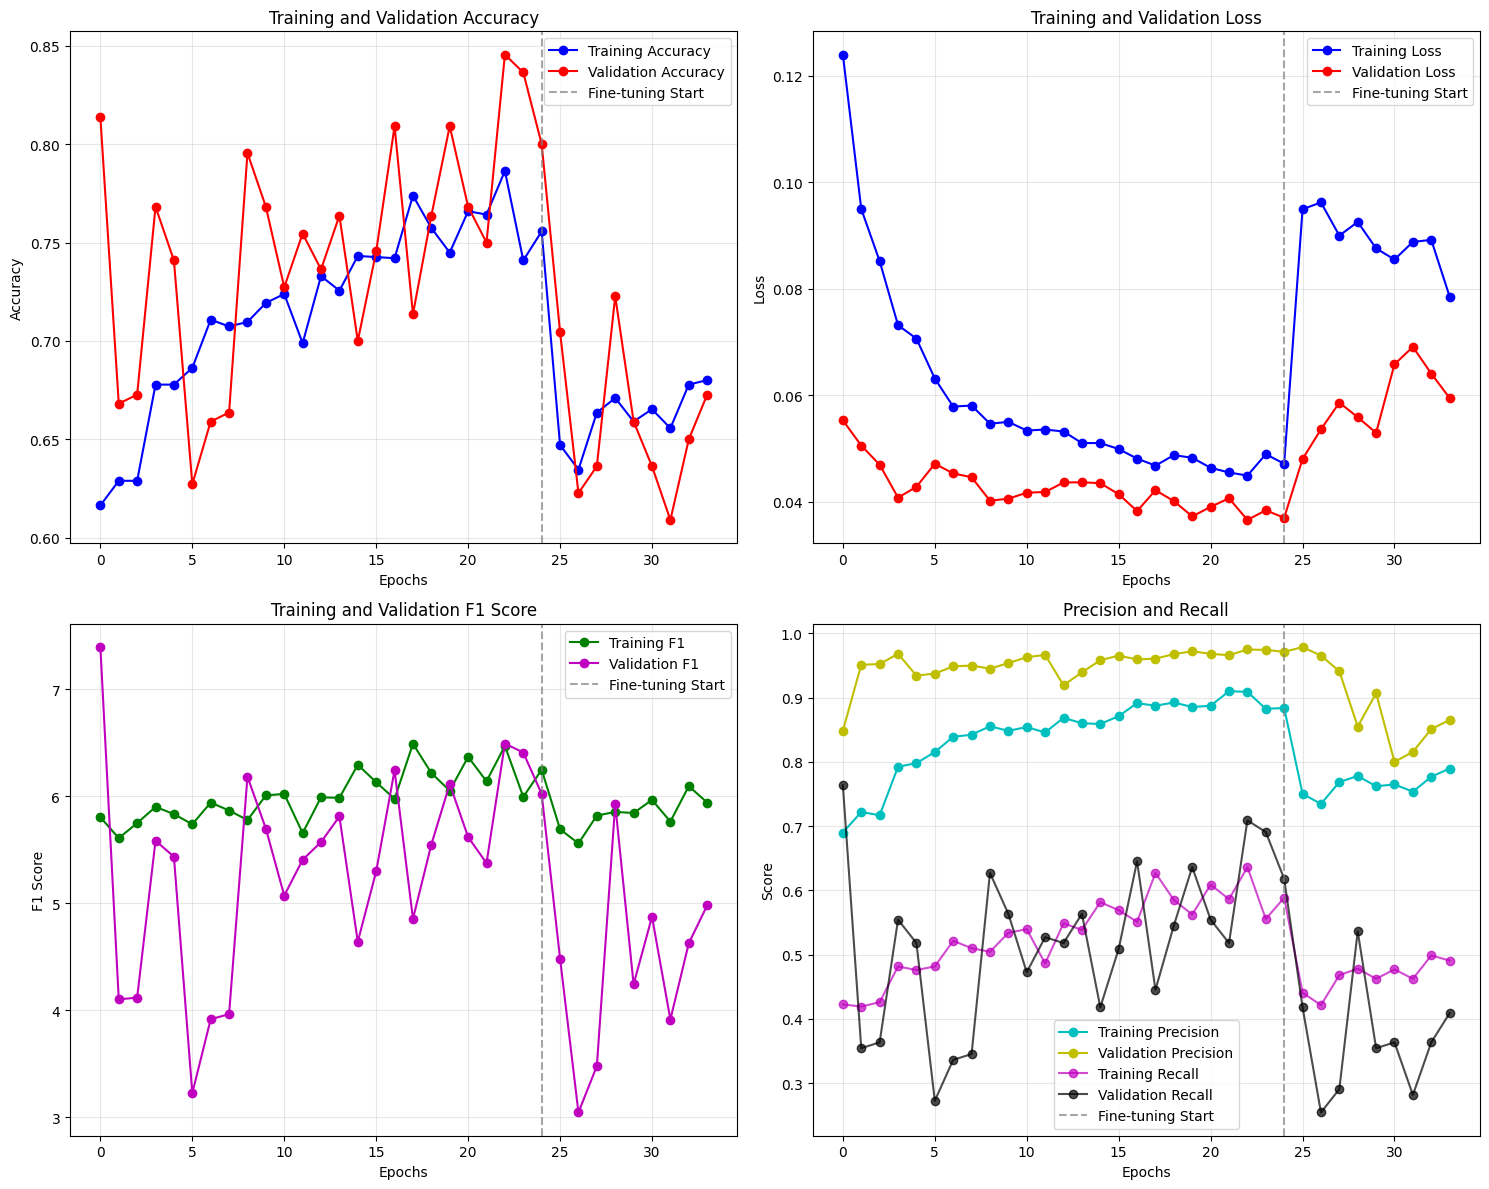

✅ Training visualization complete!


In [15]:
# Step 9: Plot Training History
def plot_training_history(history1, history2):
    """Plot combined training history from both phases"""

    # Combine histories
    combined_history = {}
    for key in history1.history.keys():
        combined_history[key] = history1.history[key] + history2.history[key]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot accuracy
    axes[0,0].plot(combined_history['accuracy'], 'bo-', label='Training Accuracy')
    axes[0,0].plot(combined_history['val_accuracy'], 'ro-', label='Validation Accuracy')
    axes[0,0].axvline(x=len(history1.history['accuracy'])-1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0,0].set_title('Training and Validation Accuracy')
    axes[0,0].set_xlabel('Epochs')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Plot loss
    axes[0,1].plot(combined_history['loss'], 'bo-', label='Training Loss')
    axes[0,1].plot(combined_history['val_loss'], 'ro-', label='Validation Loss')
    axes[0,1].axvline(x=len(history1.history['loss'])-1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0,1].set_title('Training and Validation Loss')
    axes[0,1].set_xlabel('Epochs')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Plot F1 Score
    axes[1,0].plot(combined_history['f1_score'], 'go-', label='Training F1')
    axes[1,0].plot(combined_history['val_f1_score'], 'mo-', label='Validation F1')
    axes[1,0].axvline(x=len(history1.history['f1_score'])-1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1,0].set_title('Training and Validation F1 Score')
    axes[1,0].set_xlabel('Epochs')
    axes[1,0].set_ylabel('F1 Score')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Plot Precision and Recall
    axes[1,1].plot(combined_history['precision'], 'co-', label='Training Precision')
    axes[1,1].plot(combined_history['val_precision'], 'yo-', label='Validation Precision')
    axes[1,1].plot(combined_history['recall'], 'mo-', label='Training Recall', alpha=0.7)
    axes[1,1].plot(combined_history['val_recall'], 'ko-', label='Validation Recall', alpha=0.7)
    axes[1,1].axvline(x=len(history1.history['precision'])-1, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1,1].set_title('Precision and Recall')
    axes[1,1].set_xlabel('Epochs')
    axes[1,1].set_ylabel('Score')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history_phase1, history_phase2)

print("✅ Training visualization complete!")

🧪 Testing enhanced model on random image...


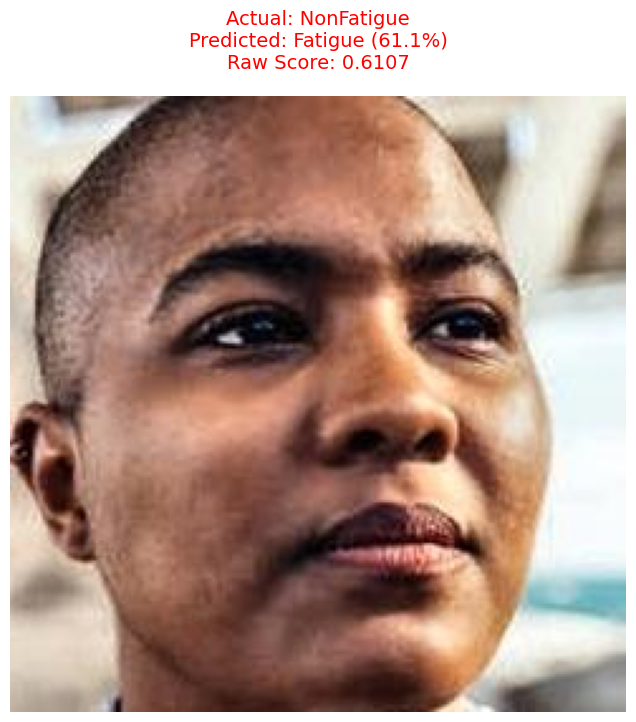

✅ Enhanced model testing complete!


In [17]:
# Step 10: Enhanced Real-time Testing Function
def test_enhanced_model_on_single_image():
    """Test the enhanced model on a single random image"""

    # Load the final model
    model = tf.keras.models.load_model(
        '/content/drive/MyDrive/my_models/enhanced_model_final.keras',
        custom_objects={'focal_loss_fixed': focal_loss(), 'f1_score': f1_score}
    )

    # Get a random image
    import random
    supported_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
    all_image_paths = [p for p in DATA_ROOT.rglob('*') if p.suffix.lower() in supported_exts]
    random_image_path = random.choice(all_image_paths)

    # Load and preprocess the image
    img_data = tf.io.read_file(str(random_image_path))
    img = tf.image.decode_image(img_data, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.keras.applications.vgg16.preprocess_input(img * 255.0)
    img = tf.expand_dims(img, axis=0)

    # Make prediction
    prediction_prob = model.predict(img, verbose=0)[0][0]
    predicted_class_index = int(prediction_prob > 0.5)
    predicted_class_name = ['NonFatigue', 'Fatigue'][predicted_class_index]
    confidence = prediction_prob if predicted_class_index == 1 else 1 - prediction_prob

    # Get actual label
    actual_class_name = random_image_path.parent.name

    # Display result
    display_image = plt.imread(random_image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(display_image)
    plt.axis('off')

    title_color = 'green' if predicted_class_name == actual_class_name else 'red'
    plt.title(
        f"Actual: {actual_class_name}\n"
        f"Predicted: {predicted_class_name} ({confidence:.1%})\n"
        f"Raw Score: {prediction_prob:.4f}",
        color=title_color,
        fontsize=14,
        pad=20
    )
    plt.show()

    return prediction_prob, predicted_class_name, actual_class_name

# Test the enhanced model
print("🧪 Testing enhanced model on random image...")
prob, pred, actual = test_enhanced_model_on_single_image()

print("✅ Enhanced model testing complete!")